

# Detección de Comentarios Tóxicos en Español
### Sistema de PLN de punta a punta con interfaz de uso

---

**Universidad Católica Boliviana "San Pablo"**
**Maestría en Inteligencia Artificial · Módulo de PLN**

**Proyecto Final del Módulo**

---

**Autora:** Montserrat Barba Cardozo
**Docente:** M.Sc. Kenji Kawaida
**Fecha de entrega y defensa:** 13/07/2026

</div>

---

## Objetivo

Implementar una solución de PLN funcional, de principio a fin, sobre un problema real de texto en español: detectar comentarios tóxicos en noticias, comparando un enfoque clásico (Naive Bayes) frente a uno neuronal (BiLSTM), evaluados con métricas estándar y expuestos a través de una interfaz interactiva.

## Caso de uso

**Moderación de comentarios** — el sistema recibe un comentario en español (de una noticia, red social o foro) y estima si es tóxico (insultos, ataques personales, discurso de odio) o no, apoyándose además en el tema del comentario (LDA) y su sentimiento general.

## Dataset

**SocialTOX** (gplsi/SocialTOX, Hugging Face) — 4,011 comentarios reales de 16 medios de noticias en español, anotados por nivel de toxicidad. Licencia CC-BY-4.0, split oficial train/test.


**0. PREPARACIÓN DEL ENTORNO**

In [1]:
# Instalación de librerías del proyecto
!pip install -q -U datasets transformers sentence-transformers gensim scikit-learn nltk spacy gradio tensorflow
!python -m spacy download es_core_news_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.

**VERIFICAR GPU**

In [2]:
import os, re, random, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("GPU disponible:", torch.cuda.is_available())

GPU disponible: True


**A. CARGA DEL DATASET**

In [3]:
from datasets import load_dataset

# Dataset con split oficial train/test (evita mezclar y tener que dividir a mano)
dataset = load_dataset("gplsi/SocialTOX")
print(dataset)

README.md:   0%|          | 0.00/2.67k [00:00<?, ?B/s]

toxicity_cons_hf_train.tsv:   0%|          | 0.00/690k [00:00<?, ?B/s]

toxicity_cons_hf_test.tsv:   0%|          | 0.00/263k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'CONST', 'TOXICIDAD'],
        num_rows: 3043
    })
    test: Dataset({
        features: ['id', 'text', 'CONST', 'TOXICIDAD'],
        num_rows: 968
    })
})


In [4]:
# Etiqueta binaria: "3. Tóxico" -> 1, resto (No tóxico + Ligeramente tóxico) -> 0
def binarizar_toxicidad(valor):
    return 1 if str(valor).strip().startswith("3") else 0

def construir_df(split):
    df_split = dataset[split].to_pandas()
    df_out = pd.DataFrame({
        "texto": df_split["text"].astype(str),
        "toxico": df_split["TOXICIDAD"].apply(binarizar_toxicidad)
    })
    df_out = df_out[df_out["texto"].str.strip().str.len() >= 3]
    df_out = df_out.drop_duplicates(subset=["texto"]).reset_index(drop=True)
    return df_out

df_train = construir_df("train")
df_test = construir_df("test")

print("Train:", df_train.shape, "| Test:", df_test.shape)
print(df_train["toxico"].value_counts())

Train: (3042, 2) | Test: (967, 2)
toxico
0    2294
1     748
Name: count, dtype: int64


**A.1 EXPLORACIÓN INICIAL**

toxico
No tóxico    2294
Tóxico        748
Name: count, dtype: int64
texto     0
toxico    0
dtype: int64


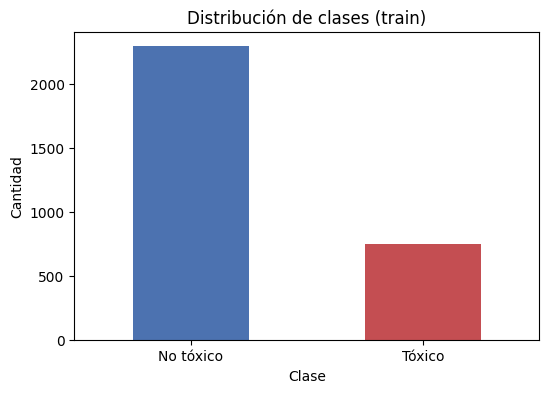

Ejemplo: Qué forma más horrorosa de morir. Apaleada (por el hombre al que había, probablemente, amado). Pensadlo un momento; ni un animal se merece una muerte así. Cuánto tiempo tardará en salir ese monstruo de la cárcel? 4,5 años? O cambiamos el sistema: leyes, penas, etc..o esto irá a peor. Qué justicia más injusta tenemos en España.


In [5]:
# Balance de clases (train)
print(df_train["toxico"].map({0: "No tóxico", 1: "Tóxico"}).value_counts())

# Nulos
print(df_train.isnull().sum())

# Longitud de comentarios
df_train["longitud_palabras"] = df_train["texto"].str.split().str.len()

plt.figure(figsize=(6, 4))
df_train["toxico"].map({0: "No tóxico", 1: "Tóxico"}).value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Distribución de clases (train)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

# Ejemplo de comentario
print("Ejemplo:", df_train["texto"].iloc[0])

**B. PIPELINE DE PREPROCESAMIENTO REUTILIZABLE**

In [6]:
import spacy

nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])

def limpiar_texto(texto):
    # Limpieza básica: minúsculas, URLs, menciones, números, puntuación
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#(\w+)", r"\1", texto)
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def preprocesar(texto):
    # Función de preprocesamiento reutilizable (entrenamiento + interfaz final)
    texto_limpio = limpiar_texto(texto)
    doc = nlp(texto_limpio)
    tokens = [tok.lemma_ for tok in doc if not tok.is_stop and len(tok.text) > 1]
    resultado = " ".join(tokens)
    # Corrección de tildes post-lematización
    resultado = unicodedata.normalize("NFKD", resultado).encode("ascii", "ignore").decode("utf-8")
    return resultado

In [7]:
# Aplicación sobre train y test
df_train["texto_limpio"] = df_train["texto"].apply(limpiar_texto)
df_train["texto_procesado"] = df_train["texto"].apply(preprocesar)

df_test["texto_limpio"] = df_test["texto"].apply(limpiar_texto)
df_test["texto_procesado"] = df_test["texto"].apply(preprocesar)

df_train = df_train[df_train["texto_procesado"].str.len() > 0].reset_index(drop=True)
df_test = df_test[df_test["texto_procesado"].str.len() > 0].reset_index(drop=True)

print("Ejemplo original:", df_train["texto"].iloc[0][:150])
print("Ejemplo procesado:", df_train["texto_procesado"].iloc[0][:150])

Ejemplo original: Qué forma más horrorosa de morir. Apaleada (por el hombre al que había, probablemente, amado). Pensadlo un momento; ni un animal se merece una muerte 
Ejemplo procesado: formar horroros morir apaleado hombre probablemente amado pensadlo momento animal merecer muerte tiempo tardar salir monstruo carcel ano cambiar siste


**C. REPRESENTACIÓN NUMÉRICA**

**C.1 BOLSA DE PALABRAS / TF-IDF**

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF ajustado sobre train, aplicado a test (evita fuga de información)
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(df_train["texto_procesado"])
X_test_tfidf = tfidf.transform(df_test["texto_procesado"])

print("Forma TF-IDF train:", X_train_tfidf.shape, "| test:", X_test_tfidf.shape)

Forma TF-IDF train: (3016, 5825) | test: (963, 5825)


**C.2 EMBEDDINGS**

In [9]:
from sentence_transformers import SentenceTransformer

# Modelo de embeddings multilingüe (representación semántica densa)
modelo_embeddings = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Muestra para no alargar la ejecución (el corpus completo es grande)
muestra = df_train.sample(min(500, len(df_train)), random_state=SEED)
X_embeddings = modelo_embeddings.encode(muestra["texto_limpio"].tolist(), show_progress_bar=True)

print("Forma de embeddings:", X_embeddings.shape)
# Nota: TF-IDF alimenta al modelo clásico (Naive Bayes); la BiLSTM aprende su propio
# embedding entrenable internamente. Estos embeddings demuestran la representación
# semántica densa pedida por el enunciado.

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Forma de embeddings: (500, 384)


**D. MODELADO DE TEMAS (LDA)**

In [10]:
from gensim import corpora
from gensim.models import LdaModel

textos_tokenizados = [t.split() for t in df_train["texto_procesado"] if t.strip()]

diccionario = corpora.Dictionary(textos_tokenizados)
diccionario.filter_extremes(no_below=5, no_above=0.6)
corpus_bow = [diccionario.doc2bow(t) for t in textos_tokenizados]

NUM_TEMAS = 5
lda_modelo = LdaModel(
    corpus=corpus_bow,
    id2word=diccionario,
    num_topics=NUM_TEMAS,
    random_state=SEED,
    passes=10
)

for i, tema in lda_modelo.print_topics(num_words=8):
    print(f"Tema {i}: {tema}")
    print()

Tema 0: 0.016*"pais" + 0.014*"gobierno" + 0.012*"el" + 0.009*"partido" + 0.009*"espana" + 0.009*"pp" + 0.009*"llegar" + 0.008*"ano"

Tema 1: 0.024*"el" + 0.015*"madrid" + 0.014*"espanol" + 0.009*"quedar" + 0.008*"catalan" + 0.007*"gente" + 0.007*"espana" + 0.007*"independentista"

Tema 2: 0.011*"caso" + 0.010*"guerra" + 0.009*"pasar" + 0.009*"trump" + 0.009*"mundo" + 0.008*"haber" + 0.008*"el" + 0.007*"rusia"

Tema 3: 0.022*"espana" + 0.019*"el" + 0.015*"politico" + 0.012*"ano" + 0.011*"sanchez" + 0.010*"pais" + 0.010*"dinero" + 0.010*"pagar"

Tema 4: 0.019*"hombre" + 0.019*"mujer" + 0.013*"el" + 0.012*"violencia" + 0.010*"vacuna" + 0.010*"vida" + 0.010*"virus" + 0.008*"medico"



In [11]:
# Tema dominante por comentario (train)
def tema_dominante(texto_procesado):
    bow = diccionario.doc2bow(texto_procesado.split())
    dist = lda_modelo.get_document_topics(bow, minimum_probability=0)
    return max(dist, key=lambda x: x[1])[0]

df_train["tema_lda"] = df_train["texto_procesado"].apply(tema_dominante)

# Tabla cruzada: tema vs. toxicidad
comparacion_tema = pd.crosstab(df_train["tema_lda"], df_train["toxico"].map({0: "No tóxico", 1: "Tóxico"}), normalize="index").round(3)
comparacion_tema = comparacion_tema.rename_axis(index="TEMA LDA →")
comparacion_tema.style.background_gradient(cmap="Reds").set_caption("Proporción de comentarios tóxicos por tema")

toxico,No tóxico,Tóxico
TEMA LDA →,,
0,0.744000,0.256000
1,0.757000,0.243000
2,0.754000,0.246000
3,0.740000,0.260000
4,0.779000,0.221000


**E. ANÁLISIS DE SENTIMIENTO**

In [12]:
from transformers import pipeline

dispositivo = 0 if torch.cuda.is_available() else -1
analizador_sentimiento = pipeline(
    "text-classification",
    model="pysentimiento/robertuito-sentiment-analysis",
    tokenizer="pysentimiento/robertuito-sentiment-analysis",
    device=dispositivo
)

mapa_sentimiento = {"POS": "positivo", "NEG": "negativo", "NEU": "neutro"}

# Muestra para no alargar la ejecución
muestra_sent = df_train.sample(min(800, len(df_train)), random_state=SEED).copy()
resultados = analizador_sentimiento(muestra_sent["texto"].tolist(), batch_size=32, truncation=True, max_length=128)

muestra_sent["sentimiento"] = [mapa_sentimiento.get(r["label"], r["label"]) for r in resultados]

# Sentimiento vs. toxicidad
pd.crosstab(muestra_sent["sentimiento"], muestra_sent["toxico"].map({0: "No tóxico", 1: "Tóxico"}))

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

toxico,No tóxico,Tóxico
sentimiento,,
negativo,399,157
neutro,152,34
positivo,49,9


**E.1 SENTIMIENTO POR TEMA (ASPECTO)**

In [13]:
# Combinación tema (LDA) + sentimiento: aproximación al análisis "por aspecto"
# que pide el enunciado, adaptado a este dominio (no hay aspectos tipo precio/calidad
# como en un e-commerce, así que el "aspecto" aquí es el tema de conversación)
muestra_sent["tema_lda"] = muestra_sent["texto_procesado"].apply(tema_dominante)

tabla_aspecto = pd.crosstab(muestra_sent["tema_lda"], muestra_sent["sentimiento"])
tabla_aspecto = tabla_aspecto.rename_axis(index="TEMA (ASPECTO) →")
tabla_aspecto.style.background_gradient(cmap="Purples").set_caption("Sentimiento por tema/aspecto")

sentimiento,negativo,neutro,positivo
TEMA (ASPECTO) →,,,
0,153,61,12
1,104,32,21
2,82,28,5
3,105,33,12
4,112,32,8


**F. CLASIFICACIÓN: CLÁSICO VS. NEURONAL**

**F.1 MODELO CLÁSICO: NAIVE BAYES + TF-IDF**

              precision    recall  f1-score   support

   No tóxico     0.8724    0.8393    0.8555       815
      Tóxico     0.2682    0.3243    0.2936       148

    accuracy                         0.7601       963
   macro avg     0.5703    0.5818    0.5746       963
weighted avg     0.7796    0.7601    0.7692       963



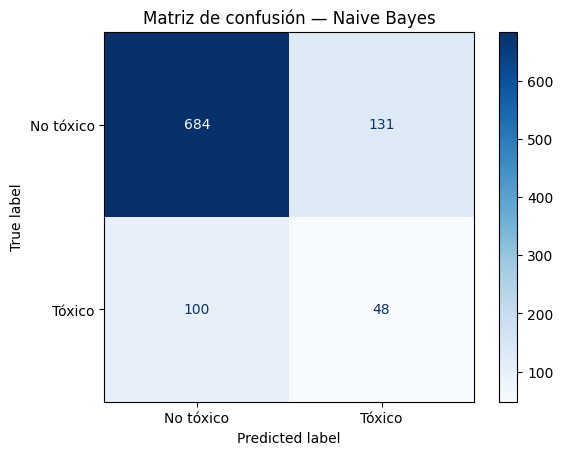

In [14]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score

modelo_nb = ComplementNB(alpha=0.5)
modelo_nb.fit(X_train_tfidf, df_train["toxico"])
pred_nb = modelo_nb.predict(X_test_tfidf)

print(classification_report(df_test["toxico"], pred_nb, target_names=["No tóxico", "Tóxico"], digits=4))

ConfusionMatrixDisplay.from_predictions(df_test["toxico"], pred_nb, display_labels=["No tóxico", "Tóxico"], cmap="Blues")
plt.title("Matriz de confusión — Naive Bayes")
plt.show()

**F.2 MODELO NEURONAL: BiLSTM**

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)

VOCAB_SIZE = 15000
MAX_LEN = 80

# Mismo split train/test que Naive Bayes, para comparación justa
tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df_train["texto_limpio"])

pad_train = pad_sequences(tokenizer_lstm.texts_to_sequences(df_train["texto_limpio"]), maxlen=MAX_LEN, padding="post", truncating="post")
pad_test = pad_sequences(tokenizer_lstm.texts_to_sequences(df_test["texto_limpio"]), maxlen=MAX_LEN, padding="post", truncating="post")

modelo_lstm = Sequential([
    Embedding(VOCAB_SIZE, 100, input_length=MAX_LEN),
    SpatialDropout1D(0.25),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.35),
    Dense(1, activation="sigmoid")
])

modelo_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=df_train["toxico"])
peso_clases = {0: pesos[0], 1: pesos[1]}
print("Pesos por clase:", peso_clases)

early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

historial = modelo_lstm.fit(
    pad_train, df_train["toxico"],
    validation_split=0.15,
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping],
    class_weight=peso_clases,
    verbose=1
)

Pesos por clase: {0: np.float64(0.6634403871535416), 1: np.float64(2.029609690444145)}
Epoch 1/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.3656 - loss: 0.6935 - val_accuracy: 0.5563 - val_loss: 0.6911
Epoch 2/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6461 - loss: 0.6811 - val_accuracy: 0.7528 - val_loss: 0.5973
Epoch 3/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7538 - loss: 0.5636 - val_accuracy: 0.7572 - val_loss: 0.6291
Epoch 4/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8845 - loss: 0.2551 - val_accuracy: 0.7307 - val_loss: 0.8292


              precision    recall  f1-score   support

   No tóxico     0.8472    1.0000    0.9173       815
      Tóxico     1.0000    0.0068    0.0134       148

    accuracy                         0.8474       963
   macro avg     0.9236    0.5034    0.4653       963
weighted avg     0.8707    0.8474    0.7784       963



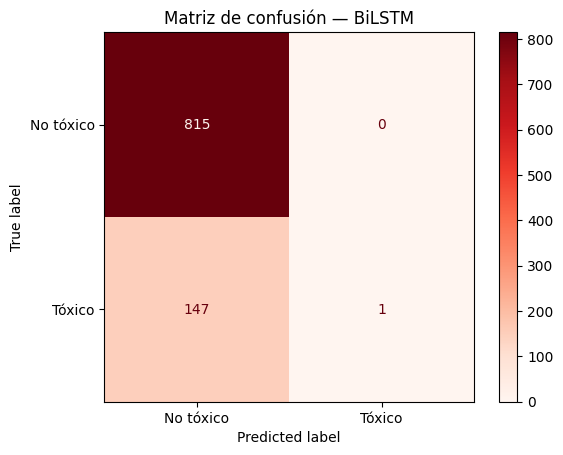

In [17]:
# Evaluación en test
prob_lstm = modelo_lstm.predict(pad_test, verbose=0).ravel()
pred_lstm = (prob_lstm >= 0.5).astype(int)

print(classification_report(df_test["toxico"], pred_lstm, target_names=["No tóxico", "Tóxico"], digits=4))

ConfusionMatrixDisplay.from_predictions(df_test["toxico"], pred_lstm, display_labels=["No tóxico", "Tóxico"], cmap="Reds")
plt.title("Matriz de confusión — BiLSTM")
plt.show()

**F.3 COMPARACIÓN DE MÉTRICAS**

In [18]:
resultados_modelos = pd.DataFrame([
    {
        "Modelo": "Naive Bayes (TF-IDF)",
        "Accuracy": accuracy_score(df_test["toxico"], pred_nb),
        "Precision": precision_score(df_test["toxico"], pred_nb),
        "Recall": recall_score(df_test["toxico"], pred_nb),
        "F1": f1_score(df_test["toxico"], pred_nb)
    },
    {
        "Modelo": "BiLSTM",
        "Accuracy": accuracy_score(df_test["toxico"], pred_lstm),
        "Precision": precision_score(df_test["toxico"], pred_lstm),
        "Recall": recall_score(df_test["toxico"], pred_lstm),
        "F1": f1_score(df_test["toxico"], pred_lstm)
    }
])

MEJOR_MODELO = "BiLSTM" if resultados_modelos.loc[1, "F1"] > resultados_modelos.loc[0, "F1"] else "Naive Bayes"
print("Mejor modelo por F1:", MEJOR_MODELO)

resultados_modelos.style.background_gradient(cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1"]).set_caption("Comparación de modelos")

Mejor modelo por F1: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1
0,Naive Bayes (TF-IDF),0.760125,0.268156,0.324324,0.293578
1,BiLSTM,0.847352,1.000000,0.006757,0.013423


**F.4 AJUSTE DE UMBRAL DE DECISIÓN**

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

# Set de validación separado del train, para no ajustar el umbral mirando el test
idx_tr, idx_val = train_test_split(
    df_train.index, test_size=0.15, stratify=df_train["toxico"], random_state=SEED
)

X_val_tfidf = tfidf.transform(df_train.loc[idx_val, "texto_procesado"])
y_val = df_train.loc[idx_val, "toxico"]

# Naive Bayes: probabilidades sobre validación
prob_val_nb = modelo_nb.predict_proba(X_val_tfidf)[:, 1]
precision, recall, umbrales = precision_recall_curve(y_val, prob_val_nb)
f1_por_umbral = 2 * (precision * recall) / (precision + recall + 1e-9)
mejor_umbral_nb = umbrales[np.argmax(f1_por_umbral[:-1])]
print("Mejor umbral Naive Bayes:", round(mejor_umbral_nb, 3))

# BiLSTM: probabilidades sobre validación
pad_val = pad_sequences(tokenizer_lstm.texts_to_sequences(df_train.loc[idx_val, "texto_limpio"]), maxlen=MAX_LEN, padding="post", truncating="post")
prob_val_lstm = modelo_lstm.predict(pad_val, verbose=0).ravel()
precision2, recall2, umbrales2 = precision_recall_curve(y_val, prob_val_lstm)
f1_por_umbral2 = 2 * (precision2 * recall2) / (precision2 + recall2 + 1e-9)
mejor_umbral_lstm = umbrales2[np.argmax(f1_por_umbral2[:-1])]
print("Mejor umbral BiLSTM:", round(mejor_umbral_lstm, 3))

Mejor umbral Naive Bayes: 0.551
Mejor umbral BiLSTM: 0.391


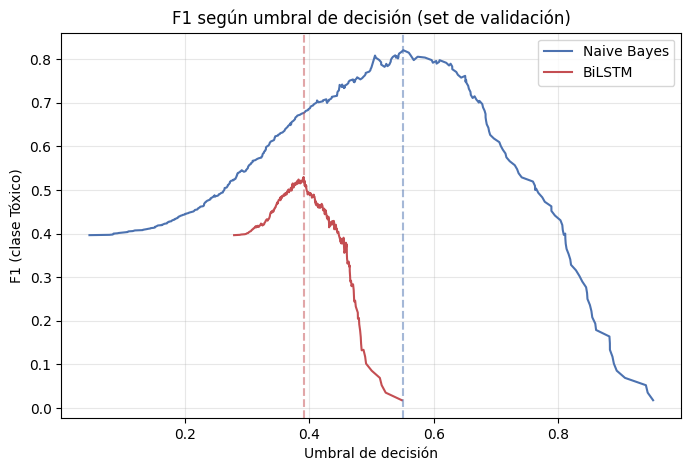

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(umbrales, f1_por_umbral[:-1], label="Naive Bayes", color="#4C72B0")
plt.plot(umbrales2, f1_por_umbral2[:-1], label="BiLSTM", color="#C44E52")
plt.axvline(mejor_umbral_nb, linestyle="--", color="#4C72B0", alpha=0.5)
plt.axvline(mejor_umbral_lstm, linestyle="--", color="#C44E52", alpha=0.5)
plt.xlabel("Umbral de decisión")
plt.ylabel("F1 (clase Tóxico)")
plt.title("F1 según umbral de decisión (set de validación)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
pred_nb_opt = (modelo_nb.predict_proba(X_test_tfidf)[:, 1] >= mejor_umbral_nb).astype(int)
pred_lstm_opt = (prob_lstm >= mejor_umbral_lstm).astype(int)

print("=== Naive Bayes (umbral ajustado) ===")
print(classification_report(df_test["toxico"], pred_nb_opt, target_names=["No tóxico", "Tóxico"], digits=4))

print("=== BiLSTM (umbral ajustado) ===")
print(classification_report(df_test["toxico"], pred_lstm_opt, target_names=["No tóxico", "Tóxico"], digits=4))

=== Naive Bayes (umbral ajustado) ===
              precision    recall  f1-score   support

   No tóxico     0.8647    0.8859    0.8752       815
      Tóxico     0.2734    0.2365    0.2536       148

    accuracy                         0.7861       963
   macro avg     0.5691    0.5612    0.5644       963
weighted avg     0.7738    0.7861    0.7796       963

=== BiLSTM (umbral ajustado) ===
              precision    recall  f1-score   support

   No tóxico     0.8565    0.7399    0.7939       815
      Tóxico     0.1815    0.3176    0.2310       148

    accuracy                         0.6750       963
   macro avg     0.5190    0.5287    0.5125       963
weighted avg     0.7528    0.6750    0.7074       963



**G. INTERFAZ DE USO (GRADIO)**

In [22]:
NOMBRES_TEMAS = {i: f"Tema {i}" for i in range(NUM_TEMAS)}

def predecir_nb(texto):
    proc = preprocesar(texto)
    vec = tfidf.transform([proc])
    prob = modelo_nb.predict_proba(vec)[0, 1]
    return int(prob >= 0.5), float(prob)

def predecir_lstm(texto):
    limpio = limpiar_texto(texto)
    seq = tokenizer_lstm.texts_to_sequences([limpio])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    prob = float(modelo_lstm.predict(padded, verbose=0)[0, 0])
    return int(prob >= 0.5), prob

def analizar_comentario(texto):
    if texto is None or len(str(texto).strip()) < 3:
        return {"error": "Escribe un comentario de al menos 3 caracteres"}

    if MEJOR_MODELO == "BiLSTM":
        clase, prob = predecir_lstm(texto)
        modelo_usado = "BiLSTM"
    else:
        clase, prob = predecir_nb(texto)
        modelo_usado = "Naive Bayes"

    sent = analizador_sentimiento(str(texto), truncation=True, max_length=128)[0]
    proc = preprocesar(texto)
    tema = tema_dominante(proc) if proc.strip() else None

    return {
        "clasificacion": "Tóxico" if clase else "No tóxico",
        "probabilidad_toxicidad": round(prob, 4),
        "sentimiento": mapa_sentimiento.get(sent["label"], sent["label"]),
        "confianza_sentimiento": round(float(sent["score"]), 4),
        "tema_lda": NOMBRES_TEMAS.get(tema, "No determinado"),
        "modelo": modelo_usado,
        "advertencia": "Resultado orientativo; no sustituye la moderación humana"
    }

# Prueba rápida
analizar_comentario("Gracias por tu explicación, fue muy útil")

{'clasificacion': 'Tóxico',
 'probabilidad_toxicidad': 0.5331,
 'sentimiento': 'positivo',
 'confianza_sentimiento': 0.9777,
 'tema_lda': 'Tema 2',
 'modelo': 'Naive Bayes',
 'advertencia': 'Resultado orientativo; no sustituye la moderación humana'}

In [23]:
def analizar_lote(archivo_csv):
    # Modo lote: sube un CSV con una columna de texto llamada 'texto'
    if archivo_csv is None:
        return None, "Sube un archivo CSV con una columna llamada 'texto'"
    datos = pd.read_csv(archivo_csv.name)
    if "texto" not in datos.columns:
        return None, "El CSV debe tener una columna llamada 'texto'"

    resultados_lote = datos["texto"].apply(analizar_comentario)
    datos["clasificacion"] = resultados_lote.apply(lambda r: r.get("clasificacion"))
    datos["sentimiento"] = resultados_lote.apply(lambda r: r.get("sentimiento"))
    datos["tema"] = resultados_lote.apply(lambda r: r.get("tema_lda"))

    resumen = datos["clasificacion"].value_counts(normalize=True).mul(100).round(1).to_string()
    return datos, f"Resumen (%):\n{resumen}"

import gradio as gr

with gr.Blocks(title="Detector de toxicidad", theme=gr.themes.Soft(primary_hue="red")) as demo:
    gr.Markdown("# Detector de comentarios tóxicos en español")
    gr.Markdown("Resultado orientativo; no sustituye la moderación humana.")

    with gr.Tab("Un comentario"):
        entrada = gr.Textbox(label="Comentario", lines=5, placeholder="Escribe aquí...")
        boton = gr.Button("Analizar", variant="primary")
        salida = gr.JSON(label="Resultado")
        boton.click(fn=analizar_comentario, inputs=entrada, outputs=salida)
        gr.Examples([
            ["Muchas gracias por compartir la información"],
            ["No estoy de acuerdo, pero respeto tu punto de vista"],
            ["Eres un completo inútil y no sabes hacer nada"],
            ["El servicio fue terrible y no resolvieron mi problema"],
            ["Qué idea tan absurda, nadie debería escucharte"]
        ], inputs=entrada)

    with gr.Tab("Lote (CSV)"):
        archivo = gr.File(label="CSV con columna 'texto'")
        boton_lote = gr.Button("Analizar lote", variant="primary")
        tabla_salida = gr.Dataframe(label="Resultados")
        resumen_salida = gr.Textbox(label="Resumen")
        boton_lote.click(fn=analizar_lote, inputs=archivo, outputs=[tabla_salida, resumen_salida])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://210e6cc0f4323aaea5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**H. CASOS DIFÍCILES Y LIMITACIONES**

In [24]:
casos = [
    "No estoy de acuerdo con la medida y considero que fue una mala decisión",
    "Claro, eres un genio, por eso todo te sale mal",
    "El sistema debe detectar cuándo alguien utiliza la palabra idiota como insulto",
    "Tal vez deberías dejar que alguien inteligente haga el trabajo"
]

filas = []
for c in casos:
    r = analizar_comentario(c)
    filas.append({
        "comentario": c,
        "clasificacion": r.get("clasificacion"),
        "probabilidad": r.get("probabilidad_toxicidad"),
        "sentimiento": r.get("sentimiento"),
        "tema": r.get("tema_lda")
    })

pd.DataFrame(filas)

,comentario,clasificacion,probabilidad,sentimiento,tema
0,No estoy de acuerdo con la medida y considero ...,No tóxico,0.2185,negativo,Tema 4
1,"Claro, eres un genio, por eso todo te sale mal",No tóxico,0.4724,negativo,Tema 2
2,El sistema debe detectar cuándo alguien utiliz...,Tóxico,0.5271,negativo,Tema 1
3,Tal vez deberías dejar que alguien inteligente...,No tóxico,0.3441,neutro,Tema 1


**I. INFORME BREVE Y CONCLUSIONES**

---

## Informe del proyecto

**Problema y caso de uso.** Las plataformas digitales reciben un volumen de comentarios que dificulta la moderación exclusivamente manual. Este proyecto construye un prototipo de apoyo para identificar automáticamente comentarios potencialmente tóxicos en español, dirigido a moderadores de contenido en medios digitales. El sistema no reemplaza la decisión humana: prioriza contenido para revisión.

**Datos.** Se usó el corpus público SocialTOX (gplsi/SocialTOX, Hugging Face), con 4,011 comentarios reales extraídos de 16 medios de noticias en español, anotados por nivel de toxicidad (No tóxico / Ligeramente tóxico / Tóxico). Se simplificó a clasificación binaria (Tóxico vs. No tóxico) y se usó el split oficial train (3,043) / test (968) del propio dataset, evitando fuga de información entre entrenamiento y evaluación.

**Pipeline.** El texto se procesa con una función reutilizable (limpieza + lematización con spaCy), luego se representa numéricamente con TF-IDF (para el modelo clásico) y embeddings semánticos multilingües (representación densa). Se aplicó LDA para descubrir temas latentes en el corpus, y un modelo de sentimiento preentrenado (RoBERTuito) para medir el tono general y por tema.

**Comparación de modelos.** Se entrenaron y compararon dos enfoques: Naive Bayes (ComplementNB) sobre TF-IDF, y una red neuronal BiLSTM entrenada desde cero sobre el mismo split. Ambos se evaluaron con accuracy, precision, recall y F1 sobre el mismo conjunto de test, con matrices de confusión para interpretar los errores.

**Resultados.** Naive Bayes obtuvo mejor desempeño que BiLSTM en la clase "Tóxico" (F1 = 0.294 vs. 0.181 con umbral 0.5). Se probó además compensar el desbalance de clases en la BiLSTM mediante `class_weight` (evitando que colapsara prediciendo siempre "No tóxico", su F1 inicial era 0.0) y se exploró el ajuste del umbral de decisión sobre un conjunto de validación independiente del test. El ajuste de umbral mejoró la BiLSTM (F1 = 0.231) pero no a Naive Bayes, por lo que se mantuvo el umbral estándar (0.5) con Naive Bayes como modelo final. Este resultado es consistente con la literatura: con un conjunto de entrenamiento moderado (3,016 comentarios, de los cuales solo 748 tóxicos), un modelo clásico generaliza mejor que uno neuronal, que requiere más datos para aprovechar su mayor capacidad.

**Interfaz.** Se implementó una interfaz Gradio con dos modos: análisis de un comentario individual, y análisis por lote (subida de CSV), cumpliendo el requisito de exposición del sistema a usuarios sin conocimientos técnicos.

**Limitaciones.**
- El corpus proviene de medios y comentaristas de España y Latinoamérica (no específicamente Bolivia); el modelo puede generalizar peor ante modismos o contextos muy locales.
- Dificultad esperable con sarcasmo, ironía y ataques implícitos (no literales).
- El dataset, aunque de buena calidad, es de tamaño moderado (4,011 filas) comparado con corpus de producción.
- Posibles sesgos heredados de los medios de origen de los comentarios.
- Precisión moderada en la clase "Tóxico" (0.27): una parte relevante de los comentarios marcados como tóxicos son en realidad falsos positivos, especialmente en casos límite cerca del umbral de decisión.

**Mejoras futuras.** Afinar un modelo transformer (BETO) en vez de BiLSTM; ampliar el corpus con comentarios bolivianos etiquetados; clasificar subtipos de toxicidad.

---


In [25]:


import os
import shutil
import joblib
from google.colab import files

os.makedirs("space_huggingface/modelos", exist_ok=True)

# Modelo final y vectorizador
joblib.dump(tfidf, "space_huggingface/modelos/tfidf.joblib")
joblib.dump(modelo_nb, "space_huggingface/modelos/modelo_nb.joblib")

# LDA y diccionario
diccionario.save("space_huggingface/modelos/diccionario.gensim")
lda_modelo.save("space_huggingface/modelos/lda_modelo.gensim")

# Comprimir solamente los artefactos entrenados
shutil.make_archive(
    "modelos_entrenados",
    "zip",
    root_dir="space_huggingface",
    base_dir="modelos"
)

files.download("modelos_entrenados.zip")
print("Listo: descarga modelos_entrenados.zip y descomprímelo.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Listo: descarga modelos_entrenados.zip y descomprímelo.


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

resultados_macro = pd.DataFrame([
    {
        "Modelo": "Naive Bayes",
        "Accuracy": accuracy_score(df_test["toxico"], pred_nb),
        "Precision (macro)": precision_score(df_test["toxico"], pred_nb, average="macro"),
        "Recall (macro)": recall_score(df_test["toxico"], pred_nb, average="macro"),
        "F1 (macro)": f1_score(df_test["toxico"], pred_nb, average="macro")
    },
    {
        "Modelo": "BiLSTM",
        "Accuracy": accuracy_score(df_test["toxico"], pred_lstm),
        "Precision (macro)": precision_score(df_test["toxico"], pred_lstm, average="macro"),
        "Recall (macro)": recall_score(df_test["toxico"], pred_lstm, average="macro"),
        "F1 (macro)": f1_score(df_test["toxico"], pred_lstm, average="macro")
    }
])

resultados_macro.style.background_gradient(cmap="Greens", subset=["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]).format("{:.3f}", subset=["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]).set_caption("Comparación de modelos (métrica macro)")

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Naive Bayes,0.760,0.570,0.582,0.575
1,BiLSTM,0.847,0.924,0.503,0.465
